In [ ]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import time

# Setting a random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("--- ⚙️ INITIALIZING DCGAN PIPELINE ---")
print(f"TensorFlow Version: {tf.__version__}")

# ==============================================================================
# 2. DATA LOADING & PREPROCESSING
# ==============================================================================
BUFFER_SIZE = 60000
BATCH_SIZE = 256

# Loading the dataset (MNIST or Fashion MNIST as base for generation)
(train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalization (CRITICAL FOR GANs):
# We reshape the images to add the color channel dimension (28x28x1).
# Unlike standard classifiers (0 to 1), GANs work best when inputs are
# normalized to the [-1, 1] range to match the Generator's Tanh activation.
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

# Batching and shuffling the dataset for optimal training
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print(f"✅ Data Pipeline Ready! Images normalized to [-1, 1].")

# ==============================================================================
# 3. ADVERSARIAL ARCHITECTURES (GENERATOR & DISCRIMINATOR)
# ==============================================================================
print("\n--- 🧠 BUILDING THE ADVERSARIAL NETWORKS ---")

def make_generator_model():
    """
    Creates the Generator Network: Maps a latent space vector (random noise)
    to a 2D image matrix (28x28x1) using Transposed Convolutions.
    """
    model = tf.keras.Sequential(name="Generator")

    # Foundation for a 7x7 image resolution
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((7, 7, 256)))

    # Upsampling to 14x14
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsampling to 14x14 (adjusting depth)
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Final Upsampling to 28x28 with Tanh activation (outputs values between -1 and 1)
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model

def make_discriminator_model():
    """
    Creates the Discriminator Network: A standard CNN image classifier
    that outputs the probability of an image being Real or Fake.
    """
    model = tf.keras.Sequential(name="Discriminator")

    # Convolutional downsampling
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Flattening and classification output
    model.add(layers.Flatten())
    model.add(layers.Dense(1)) # Outputting a raw score (logit)
    return model

# Instantiating the networks
generator = make_generator_model()
discriminator = make_discriminator_model()

print("✅ Generator and Discriminator successfully instantiated!")

--- ⚙️ INITIALIZING DCGAN PIPELINE ---
TensorFlow Version: 2.19.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Data Pipeline Ready! Images normalized to [-1, 1].

--- 🧠 BUILDING THE ADVERSARIAL NETWORKS ---
✅ Generator and Discriminator successfully instantiated!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ==============================================================================
# 4. LOSS FUNCTIONS & OPTIMIZERS
# ==============================================================================
print("\n--- ⚖️ CONFIGURING LOSS & OPTIMIZERS ---")

# Binary Cross Entropy is used since the Discriminator classifies Real (1) vs Fake (0)
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    # Discriminator wants to correctly classify real images as 1s and fake as 0s
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # Generator's sole purpose is to fool the discriminator into classifying fakes as 1s (Real)
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Separate optimizers to allow both networks to learn at their own adversarial pace
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

print("✅ Optimizers and Loss functions defined!")

# ==============================================================================
# 5. CUSTOM TRAINING STEP (THE ADVERSARIAL ENGINE)
# ==============================================================================
EPOCHS = 100
noise_dim = 100
num_examples_to_generate = 16

# Fixed noise seed to visualize the generator's evolution on the same latent vectors over time
seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function # Compiles the Python function into a static C++ graph for extreme performance
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. Generator produces fake images from random noise
        generated_images = generator(noise, training=True)

        # 2. Discriminator evaluates both real images and the fakes
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # 3. Calculate the adversarial losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # 4. Compute Gradients (Calculus / Backpropagation)
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # 5. Apply Gradients to update the weights
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

print("✅ Training Step constructed with tf.GradientTape!")


--- ⚖️ CONFIGURING LOSS & OPTIMIZERS ---
✅ Optimizers and Loss functions defined!
✅ Training Step constructed with tf.GradientTape!


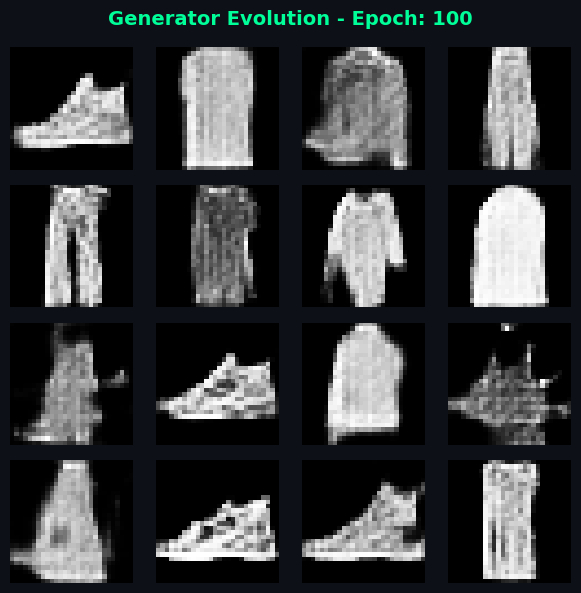


✅ GAN Training Complete! The Generator has successfully learned to create fake data.


In [ ]:
# ==============================================================================
# 6. TRAINING LOOP & REAL-TIME VISUALIZATION
# ==============================================================================
from IPython import display
import time

print("\n--- 🎬 STARTING ADVERSARIAL TRAINING ---")
print("Grab a coffee! Training a GAN takes some computational power...")

def generate_and_save_images(model, epoch, test_input):
    """
    Generates images from the latent space vector and plots them in a 4x4 grid.
    Uses 'training=False' to ensure BatchNormalization layers run in inference mode.
    """
    predictions = model(test_input, training=False)

    # Setting up a dark-themed plot for professional presentation
    fig = plt.figure(figsize=(6, 6))
    fig.patch.set_facecolor('#0d1117')

    for i in range(predictions.shape[0]):
        ax = plt.subplot(4, 4, i+1)

        # Denormalize images from [-1, 1] back to [0, 255] for plotting
        image_array = (predictions[i, :, :, 0] * 127.5 + 127.5).numpy().astype(np.uint8)

        plt.imshow(image_array, cmap='gray')
        plt.axis('off')

    plt.suptitle(f'Generator Evolution - Epoch: {epoch}', color='#00ff99', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        # Iterate over all batches in the dataset
        for image_batch in dataset:
            train_step(image_batch)

        # Clear the Jupyter output and update the visual grid
        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        print(f'⏳ Time for epoch {epoch + 1} is {time.time()-start:.2f} sec')

    # Final visual update
    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

# Executing the training loop (This will run for 100 epochs)
train(train_dataset, EPOCHS)

print("\n✅ GAN Training Complete! The Generator has successfully learned to create fake data.")